# CCGT+CCS NPV simulation

Run the CCGT+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)


In [2]:
TECHNOLOGY = 'ccgt_ccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2527.530862,44.379441,6.148274,1.911863,...,94070000.0,9.543966e+06,6.148274e+06,1.159907e+08,2.347553e+06,-3.996052e+07,-9.701246e+08,25000000.0,-38.804984,-3.880498e-05
1,1,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2553.204828,41.229368,5.417912,1.938805,...,94070000.0,8.866531e+06,5.417912e+06,5.720997e+07,2.338193e+06,2.023739e+07,-3.330467e+08,25000000.0,-13.321866,-1.332187e-05
2,2,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1639.691301,43.564899,6.038244,1.908330,...,94070000.0,9.368796e+06,6.038244e+06,6.130297e+07,1.334901e+06,1.602509e+07,-1.815575e+08,25000000.0,-7.262301,-7.262301e-06
3,3,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1494.032292,41.041380,7.037486,1.903477,...,94070000.0,8.826103e+06,7.037486e+06,6.640827e+07,1.933551e+06,9.864592e+06,-2.159950e+08,25000000.0,-8.639798,-8.639798e-06
4,4,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1820.200741,52.131530,6.780100,1.927301,...,94070000.0,1.121108e+07,6.780100e+06,3.955699e+07,2.158276e+06,3.436355e+07,-2.461784e+07,25000000.0,-0.984714,-9.847137e-07


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-425.017524,-17.000701
std,297.851669,11.914067
min,-1487.899874,-59.515995
5%,-962.929471,-38.517179
50%,-396.230931,-15.849237
95%,11.760430,0.470417
max,247.712814,9.908513


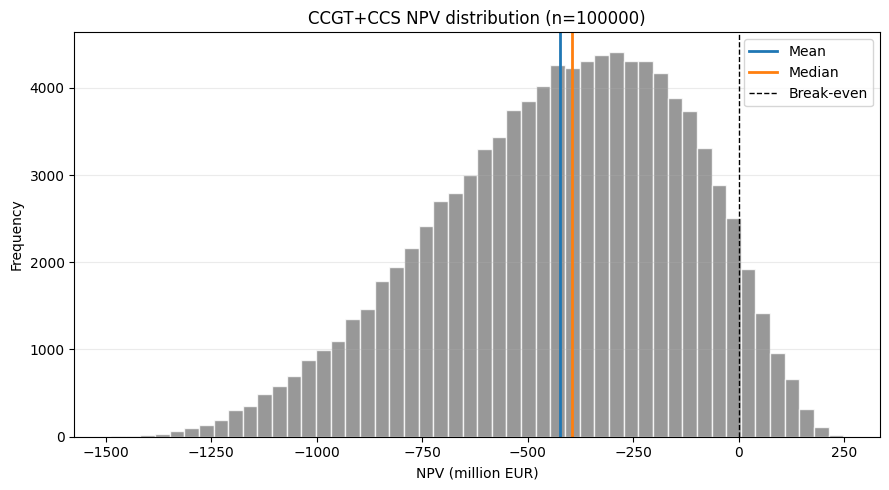

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


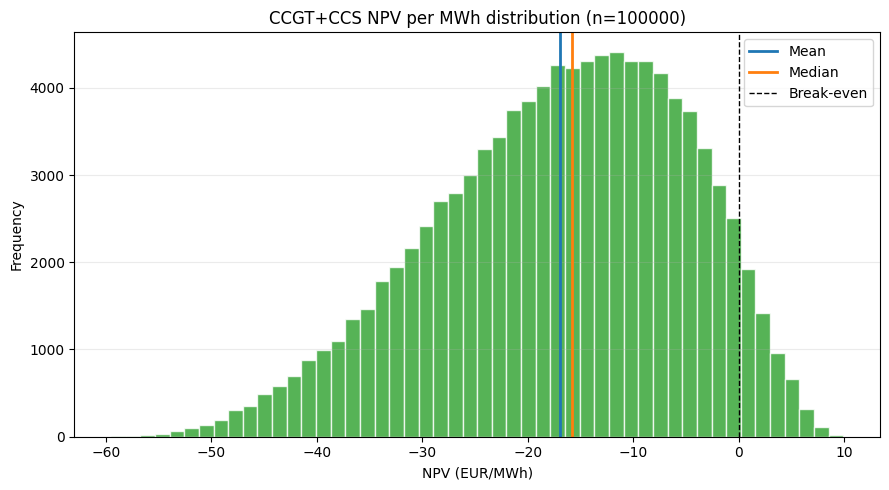

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.620071
annual_variable_opex_eur      6.274325
annual_fuel_cost_eur         75.450280
annual_emissions_cost_eur     1.792008
annual_net_cash_flow_eur      0.933316
Name: Mean annual value, million EUR, dtype: float64